In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/gdelt/clean_bigger_gdelt_finance_news.csv")
df.head()

,DATE,DocumentIdentifier,V2Themes,V2Locations,V2Organizations,V2Tone
0,DATE,DocumentIdentifier,V2Themes,V2Locations,V2Organizations,V2Tone
1,20210101000000,https://www.sunjournal.com/2020/12/31/suit-say...,"MANMADE_DISASTER_IMPLIED,44;CRIME_ILLEGAL_DRUG...","3#Biddeford, Maine, United States#US#USME#ME03...",NaN,"-3.18949343339587,1.12570356472795,4.315196998..."
2,20210101000000,https://www.startribune.com/authorities-id-tee...,"TRIAL,256;MANMADE_DISASTER_IMPLIED,381;TAX_FNC...",1#American#US#US##39.828175#-98.5795#US#81,"Attorney Office On,445;Sheriff Office,220;Sher...","-5.0314465408805,0.628930817610063,5.660377358..."
3,20210101000000,https://www.newschannel5.com/news/national/cor...,"GENERAL_HEALTH,62;GENERAL_HEALTH,578;GENERAL_H...",NaN,"Aurora Health Care,67;Aurora Health Care,752;A...","-5.52763819095477,3.01507537688442,8.542713567..."
4,20210101000000,https://www.sfchronicle.com/opinion/editorials...,"HEALTH_VACCINATION,2944;TAX_ETHNICITY_ENGLISH,...","3#Central Valley, California, United States#US...",NaN,"-2.4390243902439,2.78745644599303,5.2264808362..."


In [ ]:
print(df.shape)

(116900, 6)


In [ ]:
print(df.columns)

Index(['DATE', 'DocumentIdentifier', 'V2Themes', 'V2Locations',
       'V2Organizations', 'V2Tone'],
      dtype='object')


In [ ]:
df = df[df["DATE"] != "DATE"].copy()

In [ ]:
df.head()

,DATE,DocumentIdentifier,V2Themes,V2Locations,V2Organizations,V2Tone
1,20210101000000,https://www.sunjournal.com/2020/12/31/suit-say...,"MANMADE_DISASTER_IMPLIED,44;CRIME_ILLEGAL_DRUG...","3#Biddeford, Maine, United States#US#USME#ME03...",NaN,"-3.18949343339587,1.12570356472795,4.315196998..."
2,20210101000000,https://www.startribune.com/authorities-id-tee...,"TRIAL,256;MANMADE_DISASTER_IMPLIED,381;TAX_FNC...",1#American#US#US##39.828175#-98.5795#US#81,"Attorney Office On,445;Sheriff Office,220;Sher...","-5.0314465408805,0.628930817610063,5.660377358..."
3,20210101000000,https://www.newschannel5.com/news/national/cor...,"GENERAL_HEALTH,62;GENERAL_HEALTH,578;GENERAL_H...",NaN,"Aurora Health Care,67;Aurora Health Care,752;A...","-5.52763819095477,3.01507537688442,8.542713567..."
4,20210101000000,https://www.sfchronicle.com/opinion/editorials...,"HEALTH_VACCINATION,2944;TAX_ETHNICITY_ENGLISH,...","3#Central Valley, California, United States#US...",NaN,"-2.4390243902439,2.78745644599303,5.2264808362..."
5,20210101000000,https://www.prpeak.com/s-p-500-ends-at-another...,"GENERAL_GOVERNMENT,1189;GENERAL_GOVERNMENT,446...",1#Britain#UK#UK##54#-4#UK#4357,"Astrazeneca,4408;Td Ameritrade,2244;Oxford Uni...","-0.462107208872458,3.04990757855823,3.51201478..."


In [ ]:
df["DATE"] = pd.to_datetime(
    df["DATE"].astype(str).str[:8],
    format="%Y%m%d"
)

In [ ]:
df["DATE"].nunique()

1085

In [ ]:
print("Start:", df["DATE"].min())
print("End:", df["DATE"].max())

Start: 2021-01-01 00:00:00
End: 2023-12-22 00:00:00


The data taken from GDELT is from 2021-01-01 to 2023-12-22

In [ ]:
daily_counts = df.groupby("DATE").size()
daily_counts.describe()

,0
count,1085.000000
mean,107.741014
std,45.020600
min,3.000000
25%,74.000000
50%,100.000000
75%,134.000000
max,239.000000


In [ ]:
all_dates = pd.date_range(
    df["DATE"].min(),
    df["DATE"].max(),
    freq="D"
)

missing_dates = all_dates.difference(
    df["DATE"].drop_duplicates()
)

print("Total calendar days:", len(all_dates))
print("Days with news:", df["DATE"].nunique())
print("Days without news:", len(missing_dates))

Total calendar days: 1086
Days with news: 1085
Days without news: 1


Only for one date the news source is missing so the data seems to be good

In [ ]:
print(missing_dates.tolist())

[Timestamp('2022-11-11 00:00:00')]


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

sp500 = yf.download(
    "^GSPC",
    start="2021-01-01",
    end="2023-12-23",
    auto_adjust=True
)
sp500.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2021-01-04,3700.649902,3769.989990,3662.709961,3764.610107,5015000000
2021-01-05,3726.860107,3737.830078,3695.070068,3698.020020,4591020000
2021-01-06,3748.139893,3783.040039,3705.340088,3712.199951,6064110000
2021-01-07,3803.790039,3811.550049,3764.709961,3764.709961,5099160000
2021-01-08,3824.679932,3826.689941,3783.600098,3815.050049,4773040000


In [ ]:
print("S&P start:", sp500.index.min())
print("S&P end:", sp500.index.max())
print("Number of trading days:", len(sp500))

S&P start: 2021-01-04 00:00:00
S&P end: 2023-12-22 00:00:00
Number of trading days: 749


In [ ]:
close = sp500["Close"]

if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]

sp500_daily = pd.DataFrame({
    "Close": close
})

sp500_daily.head()

,Close
Date,
2021-01-04,3700.649902
2021-01-05,3726.860107
2021-01-06,3748.139893
2021-01-07,3803.790039
2021-01-08,3824.679932


In [ ]:
sp500_daily["Return"] = (
    np.log(
        sp500_daily["Close"] /
        sp500_daily["Close"].shift(1)
    ) * 100
)

In [ ]:
sp500_daily.head()

,Close,Return
Date,,
2021-01-04,3700.649902,NaN
2021-01-05,3726.860107,0.705763
2021-01-06,3748.139893,0.569360
2021-01-07,3803.790039,1.473826
2021-01-08,3824.679932,0.547684


In [ ]:
df["DATE"]

,DATE
1,2021-01-01
2,2021-01-01
3,2021-01-01
4,2021-01-01
5,2021-01-01
...,...
116895,2023-12-22
116896,2023-12-22
116897,2023-12-22
116898,2023-12-22


In [ ]:
sp500_daily.index

DatetimeIndex(['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15',
               ...
               '2023-12-11', '2023-12-12', '2023-12-13', '2023-12-14',
               '2023-12-15', '2023-12-18', '2023-12-19', '2023-12-20',
               '2023-12-21', '2023-12-22'],
              dtype='datetime64[ns]', name='Date', length=749, freq=None)

In [ ]:
gdelt_dates = pd.DatetimeIndex(
    df["DATE"].dt.normalize().unique()
)

sp_dates = pd.DatetimeIndex(
    sp500_daily.index.normalize()
)

In [ ]:
overlap_dates = gdelt_dates.intersection(sp_dates)

print("GDELT unique dates:", len(gdelt_dates))
print("S&P trading days:", len(sp_dates))
print("Overlapping dates:", len(overlap_dates))

GDELT unique dates: 1085
S&P trading days: 749
Overlapping dates: 748


In [ ]:
sp_without_news = sp_dates.difference(gdelt_dates)

print("S&P days without GDELT news:", len(sp_without_news))
print(sp_without_news[:20])

S&P days without GDELT news: 1
DatetimeIndex(['2022-11-11'], dtype='datetime64[ns]', freq=None)


In [ ]:
df["tone"] = (
    df["V2Tone"]
    .str.split(",")
    .str[0]
    .astype(float)
)

In [ ]:
df[["DATE", "V2Tone", "tone"]].head()

,DATE,V2Tone,tone
1,2021-01-01,"-3.18949343339587,1.12570356472795,4.315196998...",-3.189493
2,2021-01-01,"-5.0314465408805,0.628930817610063,5.660377358...",-5.031447
3,2021-01-01,"-5.52763819095477,3.01507537688442,8.542713567...",-5.527638
4,2021-01-01,"-2.4390243902439,2.78745644599303,5.2264808362...",-2.439024
5,2021-01-01,"-0.462107208872458,3.04990757855823,3.51201478...",-0.462107


In [ ]:
daily_news = (
    df.groupby("DATE")
      .agg(
          avg_tone=("tone", "mean"),
          news_count=("tone", "count")
      )
      .reset_index()
)

In [ ]:
daily_news.head(10)

,DATE,avg_tone,news_count
0,2021-01-01,-1.910296,95
1,2021-01-02,-1.741471,58
2,2021-01-03,-2.128053,74
3,2021-01-04,-1.336925,125
4,2021-01-05,-1.820376,148
5,2021-01-06,-1.287423,167
6,2021-01-07,-2.021178,135
7,2021-01-08,-2.327704,183
8,2021-01-09,-2.376380,114
9,2021-01-10,-2.043532,87


In [ ]:
daily_news["risk_signal"] = -daily_news["avg_tone"]

In [ ]:
daily_news.head()

,DATE,avg_tone,news_count,risk_signal
0,2021-01-01,-1.910296,95,1.910296
1,2021-01-02,-1.741471,58,1.741471
2,2021-01-03,-2.128053,74,2.128053
3,2021-01-04,-1.336925,125,1.336925
4,2021-01-05,-1.820376,148,1.820376


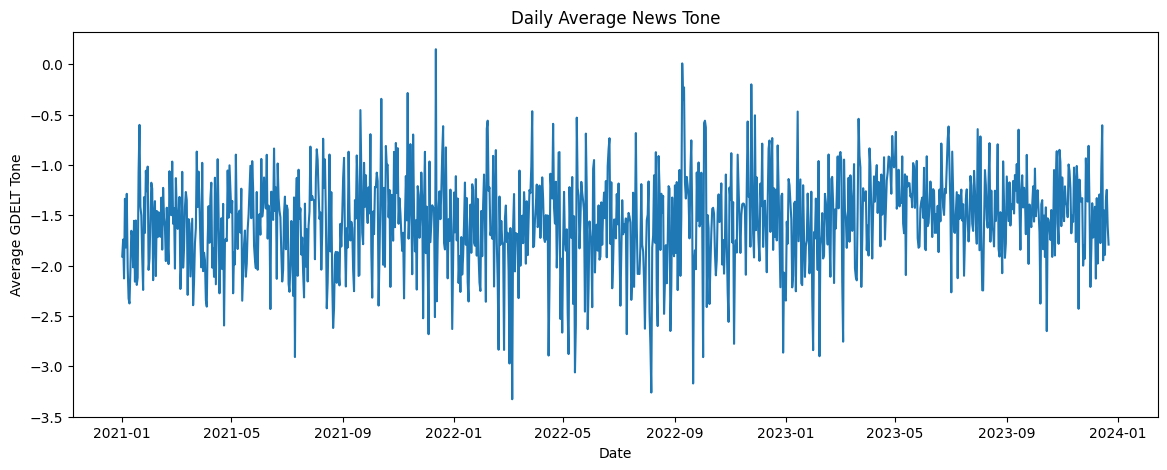

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(daily_news["DATE"], daily_news["avg_tone"])
plt.xlabel("Date")
plt.ylabel("Average GDELT Tone")
plt.title("Daily Average News Tone")
plt.show()

In [ ]:
sp500_daily = sp500_daily.reset_index()

In [ ]:
sp500_daily.head()

,Date,Close,Return
0,2021-01-04,3700.649902,NaN
1,2021-01-05,3726.860107,0.705763
2,2021-01-06,3748.139893,0.569360
3,2021-01-07,3803.790039,1.473826
4,2021-01-08,3824.679932,0.547684


In [ ]:
final_df = sp500_daily.merge(
    daily_news,
    left_on="Date",
    right_on="DATE",
    how="left"
)
final_df.head()

,Date,Close,Return,DATE,avg_tone,news_count,risk_signal
0,2021-01-04,3700.649902,NaN,2021-01-04,-1.336925,125.0,1.336925
1,2021-01-05,3726.860107,0.705763,2021-01-05,-1.820376,148.0,1.820376
2,2021-01-06,3748.139893,0.569360,2021-01-06,-1.287423,167.0,1.287423
3,2021-01-07,3803.790039,1.473826,2021-01-07,-2.021178,135.0,2.021178
4,2021-01-08,3824.679932,0.547684,2021-01-08,-2.327704,183.0,2.327704


In [ ]:
final_df = final_df.drop(columns=["DATE"])

In [ ]:
final_df.head()

,Date,Close,Return,avg_tone,news_count,risk_signal
0,2021-01-04,3700.649902,NaN,-1.336925,125.0,1.336925
1,2021-01-05,3726.860107,0.705763,-1.820376,148.0,1.820376
2,2021-01-06,3748.139893,0.569360,-1.287423,167.0,1.287423
3,2021-01-07,3803.790039,1.473826,-2.021178,135.0,2.021178
4,2021-01-08,3824.679932,0.547684,-2.327704,183.0,2.327704


In [ ]:
final_df = final_df.dropna(subset=["Return"]).copy()

In [ ]:
print(final_df.shape)
print(final_df.isna().sum())

(748, 6)
Date           0
Close          0
Return         0
avg_tone       1
news_count     1
risk_signal    1
dtype: int64


For a safer baseline Risk Signal_t-1 = Return_t

In [ ]:
final_df["risk_signal_lag1"] = final_df["risk_signal"].shift(1)

In [ ]:
final_df.head()

,Date,Close,Return,avg_tone,news_count,risk_signal,risk_signal_lag1
1,2021-01-05,3726.860107,0.705763,-1.820376,148.0,1.820376,NaN
2,2021-01-06,3748.139893,0.569360,-1.287423,167.0,1.287423,1.820376
3,2021-01-07,3803.790039,1.473826,-2.021178,135.0,2.021178,1.287423
4,2021-01-08,3824.679932,0.547684,-2.327704,183.0,2.327704,2.021178
5,2021-01-11,3799.610107,-0.657633,-1.654638,129.0,1.654638,2.327704


In [ ]:
print(final_df.shape)
print(final_df.isna().sum())

(748, 7)
Date                0
Close               0
Return              0
avg_tone            1
news_count          1
risk_signal         1
risk_signal_lag1    2
dtype: int64


In [ ]:
final_df = final_df.dropna().copy()

In [ ]:
final_df["Return"].describe()

,Return
count,745.000000
mean,0.032662
std,1.112824
min,-4.419916
25%,-0.597034
50%,0.032404
75%,0.690857
max,5.395252


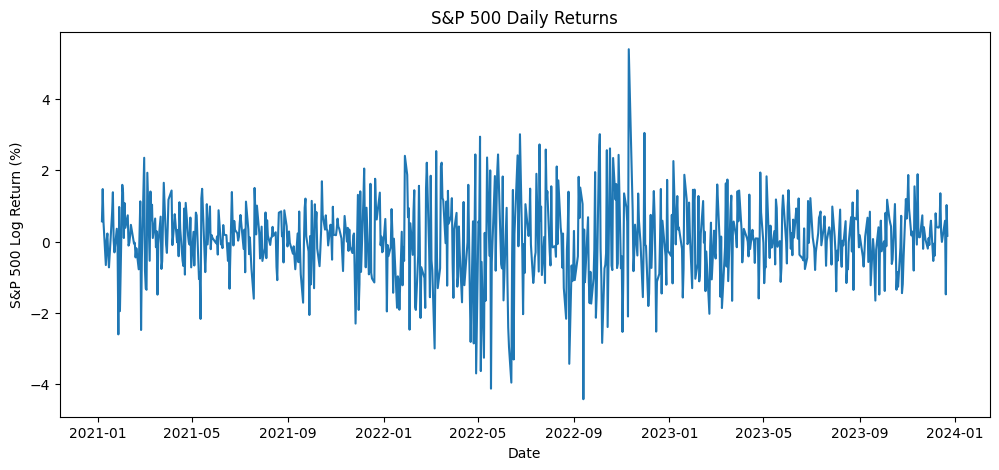

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(final_df["Date"], final_df["Return"])
plt.xlabel("Date")
plt.ylabel("S&P 500 Log Return (%)")
plt.title("S&P 500 Daily Returns")
plt.show()

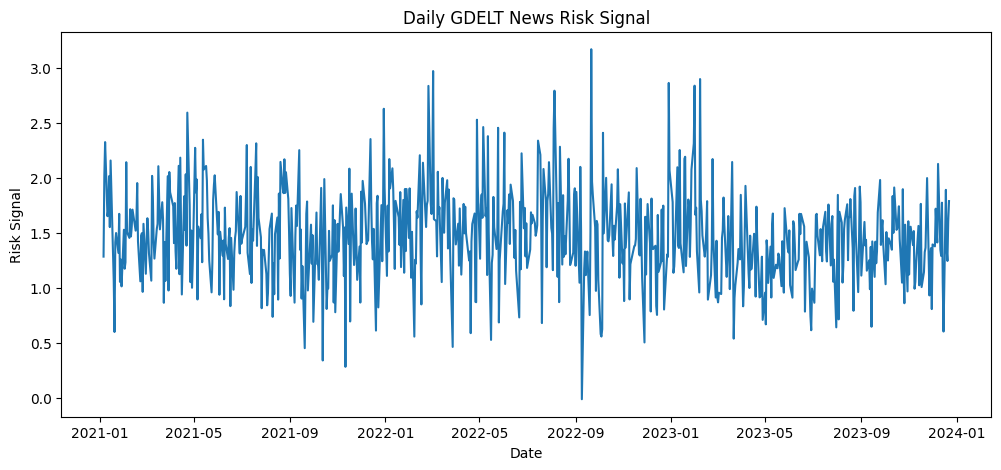

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(
    final_df["Date"],
    final_df["risk_signal"]
)

plt.xlabel("Date")
plt.ylabel("Risk Signal")
plt.title("Daily GDELT News Risk Signal")
plt.show()

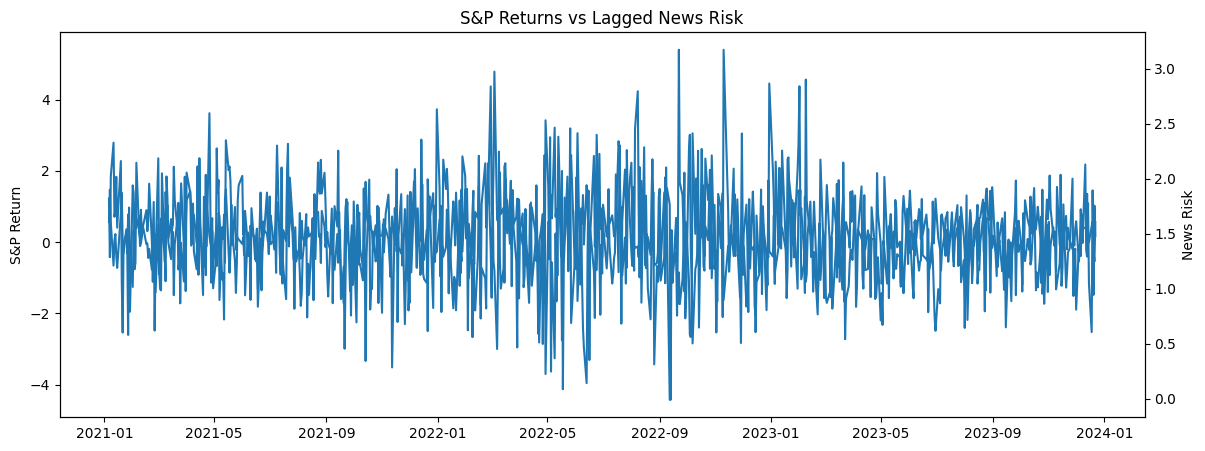

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    final_df["Date"],
    final_df["Return"],
    label="S&P Return"
)

ax2 = ax1.twinx()

ax2.plot(
    final_df["Date"],
    final_df["risk_signal_lag1"],
    label="Lagged News Risk"
)

ax1.set_ylabel("S&P Return")
ax2.set_ylabel("News Risk")

plt.title("S&P Returns vs Lagged News Risk")
plt.show()

In [ ]:
final_df[
    ["Return", "risk_signal_lag1", "news_count"]
].corr()

,Return,risk_signal_lag1,news_count
Return,1.000000,-0.083798,0.035641
risk_signal_lag1,-0.083798,1.000000,-0.160380
news_count,0.035641,-0.160380,1.000000


In [ ]:
final_df["ReturnSquared"] = final_df["Return"] ** 2

final_df[
    ["ReturnSquared", "risk_signal_lag1", "news_count"]
].corr()

,ReturnSquared,risk_signal_lag1,news_count
ReturnSquared,1.000000,-0.002769,-0.197326
risk_signal_lag1,-0.002769,1.000000,-0.160380
news_count,-0.197326,-0.160380,1.000000


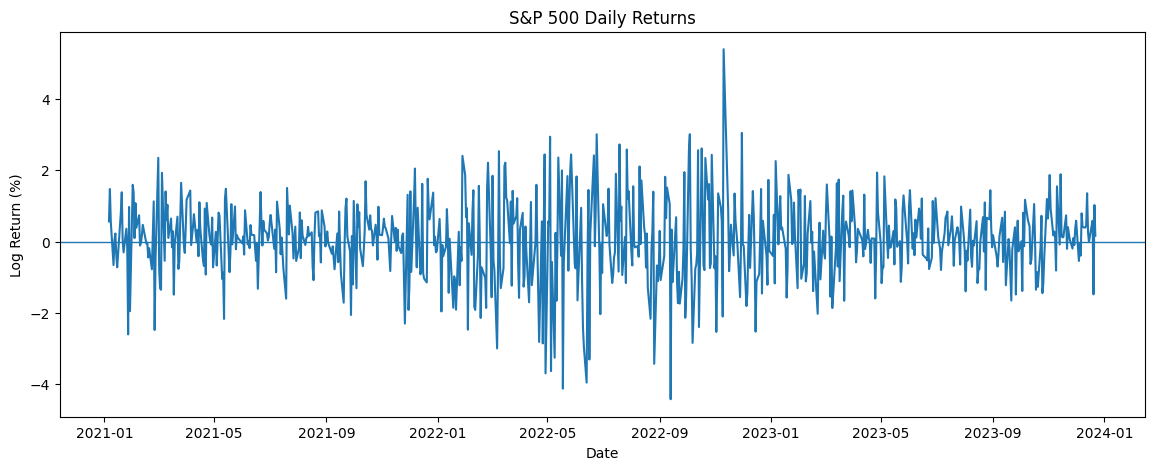

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(
    final_df["Date"],
    final_df["Return"]
)

plt.axhline(0, linewidth=1)

plt.xlabel("Date")
plt.ylabel("Log Return (%)")
plt.title("S&P 500 Daily Returns")

plt.show()

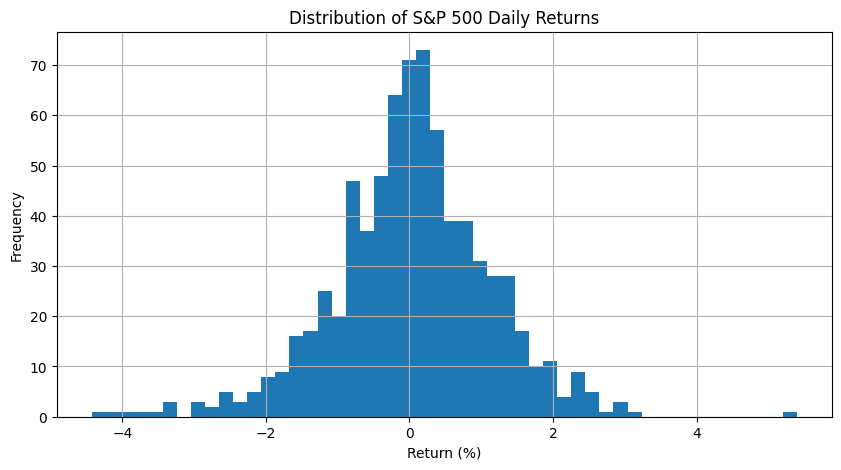

In [ ]:
final_df["Return"].hist(bins=50, figsize=(10,5))

plt.xlabel("Return (%)")
plt.ylabel("Frequency")
plt.title("Distribution of S&P 500 Daily Returns")
plt.show()

In [ ]:
final_df["Return"].describe()

,Return
count,745.000000
mean,0.032662
std,1.112824
min,-4.419916
25%,-0.597034
50%,0.032404
75%,0.690857
max,5.395252


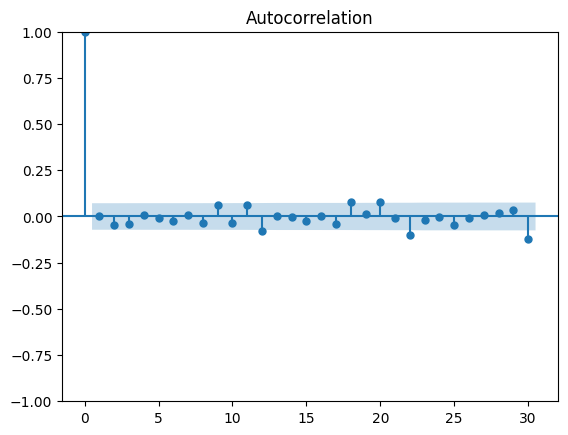

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    final_df["Return"],
    lags=30
)

plt.show()

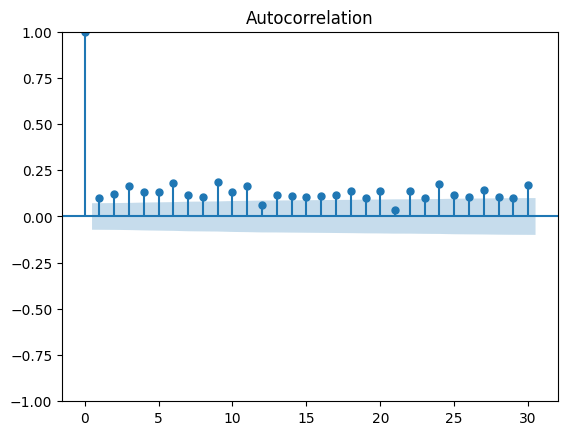

In [ ]:
plot_acf(
    final_df["ReturnSquared"],
    lags=30
)

plt.show()

rt​=μ+ϵt​



                 RETURN FORECAST
                       │
              ┌────────┴────────┐
              │                 │
            ARIMA             ARIMAX
              │                 │
        past returns      past returns
                              +
                           news risk


                VOLATILITY FORECAST
                       │
              ┌────────┴────────┐
              │                 │
            GARCH             GARCH-X
              │                 │
        past volatility    past volatility
        + past shocks           +
                           news risk

In [ ]:
final_df.head()

,Date,Close,Return,avg_tone,news_count,risk_signal,risk_signal_lag1,ReturnSquared
2,2021-01-06,3748.139893,0.569360,-1.287423,167.0,1.287423,1.820376,0.324171
3,2021-01-07,3803.790039,1.473826,-2.021178,135.0,2.021178,1.287423,2.172163
4,2021-01-08,3824.679932,0.547684,-2.327704,183.0,2.327704,2.021178,0.299957
5,2021-01-11,3799.610107,-0.657633,-1.654638,129.0,1.654638,2.327704,0.432481
6,2021-01-12,3801.189941,0.041570,-1.710616,154.0,1.710616,1.654638,0.001728


In [ ]:
split = int(len(final_df) * 0.8)

train = final_df.iloc[:split].copy()
test = final_df.iloc[split:].copy()

print("Train:", train.shape)
print("Test :", test.shape)

Train: (596, 8)
Test : (149, 8)


##### can experiment with arimax parameters
###### also i think i should use arima before arimax to show the difference after adding news signal

Arima baseline -> Return_t​=c+ϕReturn_t−1​+ϵ

Arimax Baseline -> Return_t​=c+ϕReturn_t−1​+γRiskSignal_t−1​+ϵt​

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima = SARIMAX(
    train["Return"],
    order=(1, 0, 0),
    trend="c"
)

arima_fit = arima.fit(disp=False)
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 Return   No. Observations:                  596
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -947.729
Date:                Sun, 16 Aug 2026   AIC                           1901.457
Time:                        15:07:11   BIC                           1914.628
Sample:                             0   HQIC                          1906.586
                                - 596                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0199      0.049      0.406      0.685      -0.076       0.116
ar.L1         -0.0078      0.037     -0.210      0.834      -0.081       0.065
sigma2         1.4083      0.066     21.494      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [ ]:
arima_forecast = arima_fit.get_forecast(
    steps=len(test)
)

test["arima_pred"] = arima_forecast.predicted_mean

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
test[[
    "Date",
    "Return",
    "arima_pred"
]].head()

,Date,Return,arima_pred
600,2023-05-23,-1.128547,0.019709
601,2023-05-24,-0.734551,0.019709
602,2023-05-25,0.871946,0.019709
603,2023-05-26,1.296468,0.019709
604,2023-05-30,0.001660,0.019709


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

arimax = SARIMAX(
    train["Return"],
    exog=train[["risk_signal_lag1"]],
    order=(1, 0, 0),
    trend="c"
)

arimax_fit = arimax.fit(disp=False)

print(arimax_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 Return   No. Observations:                  596
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -945.859
Date:                Sun, 16 Aug 2026   AIC                           1899.718
Time:                        15:07:12   BIC                           1917.279
Sample:                             0   HQIC                          1906.556
                                - 596                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
intercept            0.3433      0.168      2.043      0.041       0.014       0.673
risk_signal_lag1    -0.2165      0.109     -1.986      0.047      -0.430      -0.003
ar.L1                0.0017 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [ ]:
arimax_forecast = arimax_fit.get_forecast(
    steps=len(test),
    exog=test[["risk_signal_lag1"]]
)

test["arimax_pred"] = arimax_forecast.predicted_mean

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
test[[
    "Date",
    "Return",
    "arimax_pred"
]].head()

,Date,Return,arimax_pred
600,2023-05-23,-1.128547,-0.030045
601,2023-05-24,-0.734551,0.049059
602,2023-05-25,0.871946,0.056962
603,2023-05-26,1.296468,0.013652
604,2023-05-30,0.001660,0.121196


In [ ]:
print(test[["Return", "arima_pred", "arimax_pred"]].isna().sum())

Return         0
arima_pred     4
arimax_pred    4
dtype: int64


In [ ]:
print(test[["Return", "arima_pred", "arimax_pred"]].head(10))

       Return  arima_pred  arimax_pred
600 -1.128547    0.019709    -0.030045
601 -0.734551    0.019709     0.049059
602  0.871946    0.019709     0.056962
603  1.296468    0.019709     0.013652
604  0.001660    0.019709     0.121196
605 -0.612736    0.019709     0.145913
606  0.980622    0.019709    -0.004304
607  1.442981    0.019709     0.002380
608 -0.200559    0.019709     0.040807
609  0.235113    0.019709     0.091651


In [ ]:
comparison = test[["Return", "arima_pred", "arimax_pred"]].dropna()

In [ ]:
arima_mae = mean_absolute_error(
    comparison["Return"],
    comparison["arima_pred"]
)

arimax_mae = mean_absolute_error(
    comparison["Return"],
    comparison["arimax_pred"]
)

print("ARIMA MAE :", arima_mae)
print("ARIMAX MAE:", arimax_mae)

NameError: name 'mean_absolute_error' is not defined

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

arima_rmse = np.sqrt(
    mean_squared_error(
        comparison["Return"],
        comparison["arima_pred"]
    )
)

arimax_rmse = np.sqrt(
    mean_squared_error(
        comparison["Return"],
        comparison["arimax_pred"]
    )
)

print("ARIMA RMSE :", arima_rmse)
print("ARIMAX RMSE:", arimax_rmse)

ARIMA RMSE : 0.7355506143569436
ARIMAX RMSE: 0.7436000276688318


In [ ]:
arima_direction = (
    np.sign(test["Return"]) ==
    np.sign(test["arima_pred"])
).mean()

arimax_direction = (
    np.sign(test["Return"]) ==
    np.sign(test["arimax_pred"])
).mean()

print("ARIMA Directional Accuracy :", arima_direction)
print("ARIMAX Directional Accuracy:", arimax_direction)

ARIMA Directional Accuracy : 0.5436241610738255
ARIMAX Directional Accuracy: 0.4899328859060403


In [ ]:
print(test[["Return", "arima_pred", "arimax_pred"]].isna().sum())

Return         0
arima_pred     4
arimax_pred    4
dtype: int64


In [ ]:
train["arimax_resid"] = arimax_fit.resid

print(train["arimax_resid"].describe())

count    596.000000
mean       0.000004
std        1.184017
min       -4.510781
25%       -0.671349
50%        0.011262
75%        0.695499
max        5.249406
Name: arimax_resid, dtype: float64


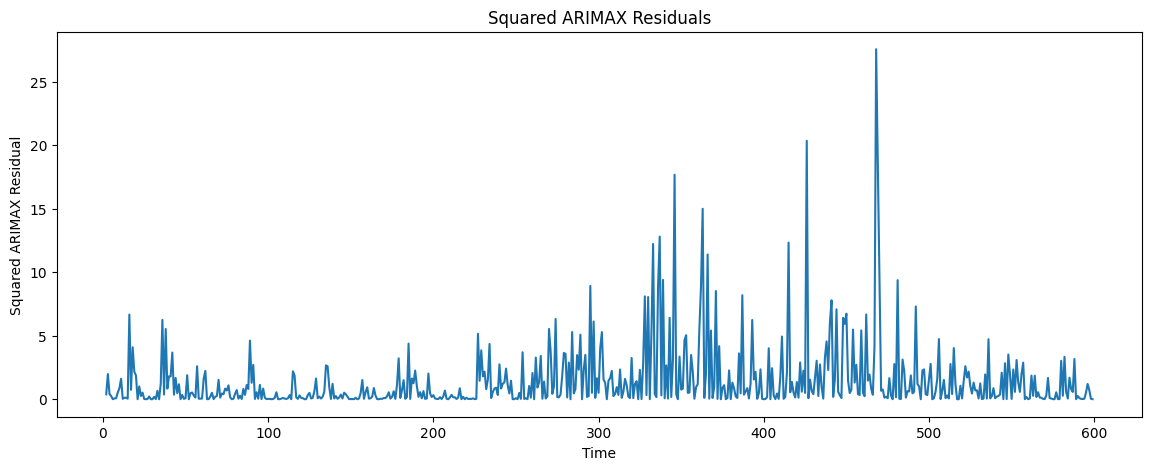

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    train["arimax_resid"] ** 2
)

plt.xlabel("Time")
plt.ylabel("Squared ARIMAX Residual")
plt.title("Squared ARIMAX Residuals")

plt.show()

In [ ]:
!pip install arch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 19.5 MB/s eta 0:00:00


In [ ]:
import arch

In [ ]:
#### can remove this
from arch import arch_model

garch = arch_model(
    train["Return"],
    mean="AR",
    lags=1,
    vol="GARCH",
    p=1,
    q=1
)

garch_fit = garch.fit()

Iteration:      1,   Func. Count:      7,   Neg. LLF: 3080.956941882907
Iteration:      2,   Func. Count:     17,   Neg. LLF: 118171650957.19093
Iteration:      3,   Func. Count:     26,   Neg. LLF: 1111103365.4407434
Iteration:      4,   Func. Count:     35,   Neg. LLF: 83154.28953147763
Iteration:      5,   Func. Count:     42,   Neg. LLF: 900.3047255707129
Iteration:      6,   Func. Count:     49,   Neg. LLF: 151176.74340453043
Iteration:      7,   Func. Count:     56,   Neg. LLF: 900.2189281146163
Iteration:      8,   Func. Count:     63,   Neg. LLF: 897.9630990782501
Iteration:      9,   Func. Count:     70,   Neg. LLF: 897.6714726998888
Iteration:     10,   Func. Count:     77,   Neg. LLF: 897.649155232738
Iteration:     11,   Func. Count:     83,   Neg. LLF: 897.6484770066907
Iteration:     12,   Func. Count:     89,   Neg. LLF: 897.6484733946077
Iteration:     13,   Func. Count:     95,   Neg. LLF: 897.6484698544848
Iteration:     14,   Func. Count:    100,   Neg. LLF: 897.6484

In [ ]:
from arch import arch_model

garch = arch_model(
    train["arimax_resid"],
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

garch_fit = garch.fit(disp="off")

print(garch_fit.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:           arimax_resid   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:               -900.370
Distribution:                  Normal   AIC:                           1806.74
Method:            Maximum Likelihood   BIC:                           1819.91
                                        No. Observations:                  596
Date:                Sun, Aug 16 2026   Df Residuals:                      596
Time:                        15:07:28   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0135  1.437e-02      0.939      0.348 

GARCH : σt2​=ω+αϵt−12​+βσt−12​

GARCHX : σt2​=ω+αϵt−12​+βσt−12​+γXt−1​​

In [ ]:
import numpy as np
from scipy.optimize import minimize

In [ ]:
eps = train["arimax_resid"].values
x = train["risk_signal_lag1"].values

In [ ]:
def garchx_nll(params, eps, x):
    omega, alpha, beta, gamma = params

    n = len(eps)
    sigma2 = np.zeros(n)

    sigma2[0] = np.var(eps)

    for t in range(1, n):
        sigma2[t] = (
            omega
            + alpha * eps[t-1]**2
            + beta * sigma2[t-1]
            + gamma * x[t-1]
        )

        if sigma2[t] <= 0:
            return 1e10

    ll = (
        0.5 * (
            np.log(2 * np.pi)
            + np.log(sigma2)
            + eps**2 / sigma2
        )
    ).sum()

    return ll

In [ ]:
initial_params = [
    0.01,
    0.05,
    0.90,
    0.01
]

In [ ]:
bounds = [
    (1e-8, None),   # omega
    (0.0, 1.0),     # alpha
    (0.0, 1.0),     # beta
    (-1.0, 1.0)     # gamma
]

constraints = {
    "type": "ineq",
    "fun": lambda p: 0.999 - p[1] - p[2]
}

In [ ]:
result = minimize(
    garchx_nll,
    initial_params,
    args=(eps, x),
    method="Nelder-Mead"
)

print(result.success)
print(result.x)
print(result.fun)

True
[0.00591468 0.05964888 0.92999467 0.00528737]
900.5176487012076


In [ ]:
result = minimize(
    garchx_nll,
    initial_params,
    args=(eps, x),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

print(result.success)
print(result.message)
print(result.x)
print(result.fun)

True
Optimization terminated successfully
[1.00000000e-08 5.94614631e-02 9.29880248e-01 9.47518646e-03]
900.5090243507614


In [ ]:
print(train["risk_signal_lag1"].describe())

count    596.000000
mean       1.497671
std        0.437263
min       -0.008045
25%        1.226777
50%        1.483023
75%        1.766358
max        3.171432
Name: risk_signal_lag1, dtype: float64


In [ ]:
garch_forecast = garch_fit.forecast(
    horizon=1,
    start=len(train)-1
)

In [ ]:
omega_g = garch_fit.params["omega"]
alpha_g = garch_fit.params["alpha[1]"]
beta_g = garch_fit.params["beta[1]"]

In [ ]:
omega_x, alpha_x, beta_x, gamma_x = result.x

In [ ]:
arimax_forecast = arimax_fit.get_forecast(
    steps=len(test),
    exog=test[["risk_signal_lag1"]]
)

test["arimax_pred"] = arimax_forecast.predicted_mean

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
test["arimax_resid"] = (
    test["Return"] - test["arimax_pred"]
)

In [ ]:

train_eps = train["arimax_resid"].values
test_eps = test["arimax_resid"].values

all_eps = np.concatenate([train_eps, test_eps])

sigma2 = np.zeros(len(all_eps))

sigma2[0] = np.var(train_eps)

for t in range(1, len(all_eps)):
    sigma2[t] = (
        omega_g
        + alpha_g * all_eps[t-1]**2
        + beta_g * sigma2[t-1]
    )

test["garch_vol"] = np.sqrt(
    sigma2[len(train):]
)

In [ ]:
test["garch_vol"]

,garch_vol
600,0.847487
601,0.868006
602,0.866822
603,0.867419
604,0.900596
...,...
744,0.753040
745,0.744243
746,NaN
747,NaN


In [ ]:
train_x = train["risk_signal_lag1"].values
test_x = test["risk_signal_lag1"].values

all_x = np.concatenate([train_x, test_x])

sigma2_x = np.zeros(len(all_eps))

sigma2_x[0] = np.var(train_eps)

for t in range(1, len(all_eps)):
    sigma2_x[t] = (
        omega_x
        + alpha_x * all_eps[t-1]**2
        + beta_x * sigma2_x[t-1]
        + gamma_x * all_x[t-1]
    )

test["garchx_vol"] = np.sqrt(
    sigma2_x[len(train):]
)

In [ ]:
test["garchx_vol"]

,garchx_vol
600,0.824073
601,0.844327
602,0.844354
603,0.844705
604,0.877750
...,...
744,0.743504
745,0.729471
746,NaN
747,NaN


In [ ]:
test["realized_vol"] = test["Return"].abs()

In [ ]:
print(test[["Return", "realized_vol", "garch_vol", "garchx_vol"]].isna().sum())

Return          0
realized_vol    0
garch_vol       3
garchx_vol      3
dtype: int64


In [ ]:
print(test[["Return", "realized_vol", "garch_vol", "garchx_vol"]].isna().sum())

print(train["arimax_resid"].isna().sum())
print(train["risk_signal_lag1"].isna().sum())
print(test["risk_signal_lag1"].isna().sum())

Return          0
realized_vol    0
garch_vol       3
garchx_vol      3
dtype: int64
0
0
0


In [ ]:
comparison = test[
    ["realized_vol", "garch_vol", "garchx_vol"]
].dropna()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

garch_mae = mean_absolute_error(
    comparison["realized_vol"],
    comparison["garch_vol"]
)

garchx_mae = mean_absolute_error(
    comparison["realized_vol"],
    comparison["garchx_vol"]
)

garch_rmse = np.sqrt(
    mean_squared_error(
        comparison["realized_vol"],
        comparison["garch_vol"]
    )
)

garchx_rmse = np.sqrt(
    mean_squared_error(
        comparison["realized_vol"],
        comparison["garchx_vol"]
    )
)

print("GARCH MAE :", garch_mae)
print("GARCH-X MAE:", garchx_mae)

print("GARCH RMSE :", garch_rmse)
print("GARCH-X RMSE:", garchx_rmse)

GARCH MAE : 0.4366081402555055
GARCH-X MAE: 0.4310394246107933
GARCH RMSE : 0.5093045006278549
GARCH-X RMSE: 0.5035893050957776


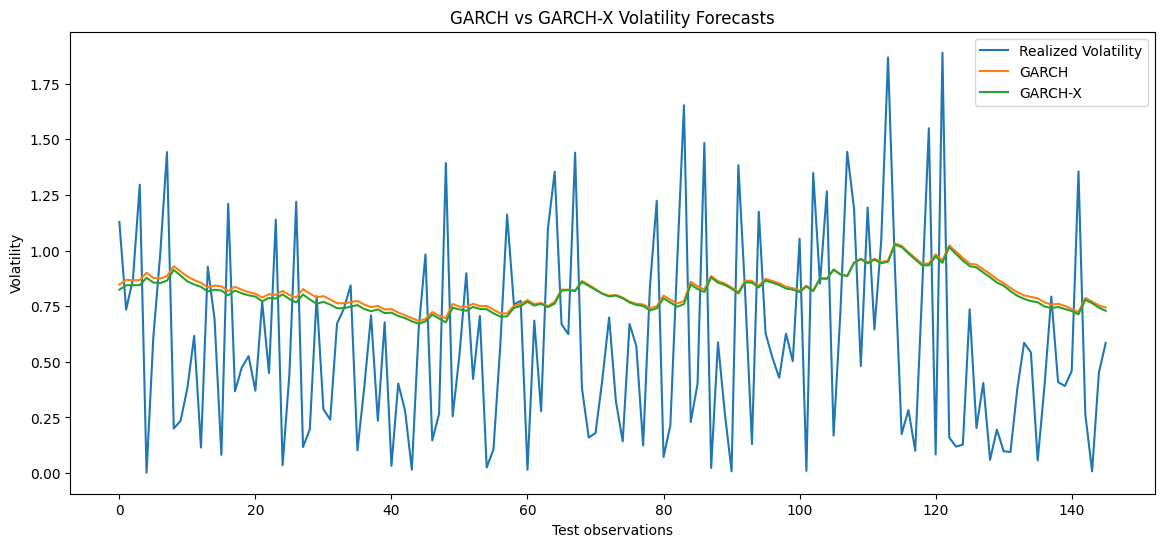

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    comparison["realized_vol"].values,
    label="Realized Volatility"
)

plt.plot(
    comparison["garch_vol"].values,
    label="GARCH"
)

plt.plot(
    comparison["garchx_vol"].values,
    label="GARCH-X"
)

plt.xlabel("Test observations")
plt.ylabel("Volatility")
plt.title("GARCH vs GARCH-X Volatility Forecasts")

plt.legend()
plt.show()

In [ ]:
print("ARIMAX parameters")
print(arimax_fit.params)

print("\nGARCH parameters")
print(garch_fit.params)

print("\nGARCH-X parameters")
print(result.x)

ARIMAX parameters
intercept           0.343312
risk_signal_lag1   -0.216467
ar.L1               0.001749
sigma2              1.399530
dtype: float64

GARCH parameters
omega       0.013495
alpha[1]    0.058785
beta[1]     0.931454
Name: params, dtype: float64

GARCH-X parameters
[1.00000000e-08 5.94614631e-02 9.29880248e-01 9.47518646e-03]


In [ ]:
print(arimax_fit.params)
print(garch_fit.params)
print(result.x)

print(train[["Date", "Return", "arimax_resid", "risk_signal_lag1"]].tail())

intercept           0.343312
risk_signal_lag1   -0.216467
ar.L1               0.001749
sigma2              1.399530
dtype: float64
omega       0.013495
alpha[1]    0.058785
beta[1]     0.931454
Name: params, dtype: float64
[1.00000000e-08 5.94614631e-02 9.29880248e-01 9.47518646e-03]
          Date    Return  arimax_resid  risk_signal_lag1
595 2023-05-16 -0.639811     -0.721324          1.213718
596 2023-05-17  1.182069      1.095897          1.184850
597 2023-05-18  0.940072      0.850127          1.182091
598 2023-05-19 -0.144691     -0.205501          1.314727
599 2023-05-22  0.015502     -0.049177          1.288315


In [ ]:
eps = train["arimax_resid"].values
x = train["risk_signal_lag1"].values

omega_g = garch_fit.params["omega"]
alpha_g = garch_fit.params["alpha[1]"]
beta_g = garch_fit.params["beta[1]"]

omega_x, alpha_x, beta_x, gamma_x = result.x

In [ ]:
sigma2_g = np.zeros(len(eps))
sigma2_g[0] = np.var(eps)

for t in range(1, len(eps)):
    sigma2_g[t] = (
        omega_g
        + alpha_g * eps[t-1]**2
        + beta_g * sigma2_g[t-1]
    )

In [ ]:
sigma2_x = np.zeros(len(eps))
sigma2_x[0] = np.var(eps)

for t in range(1, len(eps)):
    sigma2_x[t] = (
        omega_x
        + alpha_x * eps[t-1]**2
        + beta_x * sigma2_x[t-1]
        + gamma_x * x[t-1]
    )

In [ ]:
last_state = {
    "last_date": str(train["Date"].iloc[-1]),
    "last_return": float(train["Return"].iloc[-1]),
    "last_residual": float(train["arimax_resid"].iloc[-1]),
    "last_risk_signal": float(train["risk_signal_lag1"].iloc[-1]),
    "garch_variance": float(sigma2_g[-1]),
    "garchx_variance": float(sigma2_x[-1])
}

print(last_state)

{'last_date': '2023-05-22 00:00:00', 'last_return': 0.015502267980239145, 'last_residual': -0.04917719404793001, 'last_risk_signal': 1.2883150183974557, 'garch_variance': 0.756449031148954, 'garchx_variance': 0.7170228335815781}


In [ ]:
import json

with open("model_state.json", "w") as f:
    json.dump(last_state, f, indent=4)

In [ ]:
model_params = {
    "arimax": {
        "intercept": float(arimax_fit.params["intercept"]),
        "ar_l1": float(arimax_fit.params["ar.L1"]),
        "risk_signal_lag1": float(arimax_fit.params["risk_signal_lag1"])
    },
    "garch": {
        "omega": float(omega_g),
        "alpha": float(alpha_g),
        "beta": float(beta_g)
    },
    "garchx": {
        "omega": float(omega_x),
        "alpha": float(alpha_x),
        "beta": float(beta_x),
        "gamma": float(gamma_x)
    }
}

In [ ]:
with open("model_params.json", "w") as f:
    json.dump(model_params, f, indent=4)